# **Knowledge in CrewAI**

Knowledge in CrewAI is a powerful system that allows AI agents to access and utilize **external information sources** during their tasks.
Think of it as giving your agents a reference library they can consult while working.

### Key benefits of using Knowledge:
 > Enhance agents with domain-specific information

 > Support decisions with real-world data

 > Maintain context across conversations

 > Ground responses in factual information


Knowledge sources can be added at the agent or crew level. Crew level knowledge sources will be used by all agents in the crew. Agent level knowledge sources will be used by the specific agent that is preloaded with the knowledge.

# Install Libraries

In [1]:
!pip install -q crewai crewai_tools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.5/731.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 286.8/286.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.4/94.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.3/27.3 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.2/79.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978

In [12]:
!pip install -q docling

In [7]:
# import docling
# docling.__version__

'2.120.2'

# Set API Keys for LLMs & Tools

In [2]:
from google.colab import userdata
import os
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY_NEW')
# os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

# Set custom storage location for all CrewAI data


In [24]:
# os.environ["CREWAI_STORAGE_DIR"] = "./crewai_knowledge"

# Import necessary classes/methods from the package

In [5]:
from crewai import Agent, Task, Crew, LLM, Process

# Define the LLM Object

In [4]:
# Create an LLM with a temperature of 0 to ensure deterministic outputs from the LLM
# Set temperature to higher values for creative outputs from the LLM

# OPENAI LLMs
llm = LLM(
         # model="gpt-5.4-mini",
          model="gpt-5.4-nano",
          base_url="https://api.openai.com/v1",
          api_key = os.environ["OPENAI_API_KEY"],
          temperature=0.7)

# Define the Knowledge Source

In [14]:
# from crewai.knowledge.source.crew_docling_source import CrewDoclingSource

# # Create a knowledge source from web content
# content_source = CrewDoclingSource(
#     file_paths=[
#         "https://lilianweng.github.io/posts/2024-11-28-reward-hacking",
#         "https://lilianweng.github.io/posts/2024-07-07-hallucination",
#     ],
# )

### Please ensure that you create the **./knowledge** folder [default].
### Or it will be the path if you have set **os.environ["CREWAI_STORAGE_DIR"] with your specific storage path.

### All source files (e.g., .txt, .pdf, .xlsx, .json) should be placed in this folder for centralized management.


## Make sure all the source files reside inside a "**knowledge**" folder before initialize the knowledge sources and run the crew.

## Text Knowledge Source

In [15]:
%%writefile company_overview.txt

AI Technology Investment Assessment - Company Overview

Company: TechNova AI
Industry: Artificial Intelligence and Enterprise Software
Founded: 2021
Headquarters: Bangalore, India

Company Overview:
TechNova AI develops enterprise artificial intelligence solutions for
financial services, healthcare, retail, and manufacturing organizations.
Its primary products include an AI document processing platform, an
enterprise generative AI assistant, and an AI-powered predictive
analytics platform.

Products:

1. TechNova GenAI Assistant
The GenAI Assistant provides conversational interaction with enterprise
documents and internal knowledge bases. It supports retrieval-augmented
generation (RAG), document question answering, summarization, and
enterprise search.

2. TechNova Document Intelligence
This platform extracts structured information from invoices, contracts,
insurance documents, and other business documents. It uses OCR,
computer vision, and large language models.

3. TechNova Predict
TechNova Predict provides predictive analytics for customer behavior,
demand forecasting, fraud detection, and operational optimization.

Target Customers:
The company primarily targets medium and large enterprises.

Key Markets:
- Banking and Financial Services
- Healthcare
- Retail
- Manufacturing

Competitive Advantages:
- Strong enterprise AI expertise
- Integration with existing enterprise systems
- RAG-based enterprise knowledge search
- Custom AI model development
- Cloud and on-premise deployment options

Major Challenges:
- Strong competition from large technology companies
- High cost of enterprise AI deployment
- Data privacy and security requirements
- Shortage of specialized AI engineers
- Rapid evolution of generative AI technologies

Growth Opportunities:
The company plans to expand its GenAI Assistant into additional
enterprise applications. It is also exploring AI agents for workflow
automation and autonomous enterprise decision support.

Investment Consideration:
TechNova AI has significant growth potential because enterprise
adoption of generative AI and AI automation is increasing. However,
investors should consider competitive pressure, technology risk,
customer acquisition costs, and the company's ability to scale its
enterprise AI platform.


Writing company_overview.text


In [28]:
%%writefile product_roadmap.txt

TechNova AI - Product Roadmap and Strategic Initiatives

Document Type: Internal Product Strategy
Last Updated: July 2026

Overview

TechNova AI is planning several product initiatives for the next
18 months. The primary objective is to expand from AI-assisted
applications toward autonomous AI systems capable of completing
multi-step enterprise workflows.

Product Initiative 1: TechNova AgentFlow

AgentFlow is an enterprise multi-agent platform currently under
development. It allows organizations to create teams of specialized
AI agents that can collaborate to complete complex business processes.

The platform is expected to support:

- Multi-agent task decomposition
- Agent-to-agent communication
- Human approval checkpoints
- Tool integration
- Enterprise knowledge retrieval
- Persistent agent memory
- Workflow monitoring
- Agent performance evaluation

The initial target use cases are customer support automation,
financial document analysis, IT service management, and supply-chain
operations.

The internal prototype currently supports up to six cooperating
agents in a single workflow.

Expected beta release: December 2026.

Product Initiative 2: Enterprise Knowledge Hub

The Enterprise Knowledge Hub will provide organizations with a
central platform for searching and querying internal knowledge.

The system will support:

- PDF documents
- Word documents
- Internal web pages
- CSV datasets
- JSON records
- Database records

The platform will use retrieval-augmented generation to provide
answers grounded in enterprise data.

Security is a major design requirement. Each document will contain
access-control metadata so that users can only retrieve information
they are authorized to access.

Expected production release: March 2027.

Product Initiative 3: AI Decision Assistant

The AI Decision Assistant is intended to help managers analyze
business information and evaluate strategic decisions.

The assistant will combine:

- Business metrics
- Market intelligence
- Historical company data
- External news
- Predictive models
- Generative AI

The system will generate recommendations but will not automatically
execute high-impact business decisions.

Human approval will be required for decisions involving financial
transactions, employee actions, regulatory matters, or customer
account changes.

Expected pilot customers: Five enterprise customers during Q1 2027.

Technology Strategy

TechNova AI intends to maintain a model-independent architecture.
The platform should be capable of using different large language
models depending on the task.

For simple classification and extraction tasks, smaller language
models may be preferred because of their lower cost and latency.

For complex reasoning and planning tasks, more capable models will
be used.

The company is also investigating the use of locally hosted models
for customers with strict data residency requirements.

Engineering Priorities

The engineering organization has identified five priorities:

1. Reliability
   AI applications must provide predictable behavior and robust
   error handling.

2. Observability
   Every agent execution should be traceable, including model
   calls, tool calls, latency, token consumption, and failures.

3. Security
   Enterprise data must remain isolated between customers.

4. Cost Optimization
   The system should minimize unnecessary LLM calls and use
   smaller models when appropriate.

5. Evaluation
   Agent outputs must be continuously evaluated using automated
   quality metrics and human feedback.

Current Challenges

The AgentFlow prototype has experienced several problems.

First, agents sometimes produce overly detailed task decompositions,
which increases execution time and token consumption.

Second, agents occasionally call tools with invalid parameters,
resulting in tool execution failures.

Third, different language models produce different task plans for
the same business problem.

Fourth, long-running workflows can accumulate large amounts of
context, increasing memory usage and inference costs.

Fifth, the team has not yet established a standardized evaluation
framework for comparing different agent configurations.

Strategic Goal

By the end of 2027, TechNova AI aims to become a leading provider
of enterprise AI automation platforms in the Asia-Pacific market.

The company's strategy is to differentiate itself through
enterprise security, domain-specific AI agents, strong observability,
and integration with existing enterprise systems.

Management believes that successful execution of the AgentFlow and
Enterprise Knowledge Hub initiatives will be critical to achieving
this goal.

Writing prduct_roadmap.text


In [32]:
from crewai.knowledge.source.text_file_knowledge_source import TextFileKnowledgeSource

text_source = TextFileKnowledgeSource(
    file_paths=["company_overview.txt",  "product_roadmap.txt"]
)

## PDF Knowledge Source

In [ ]:
from crewai.knowledge.source.pdf_knowledge_source import PDFKnowledgeSource

pdf_source = PDFKnowledgeSource(
    file_paths=["document.pdf"]
)

## CSV Knowledge Source

In [16]:
%%writefile financial_data.csv

company,year,revenue_million,operating_profit_million,customers,employees,revenue_growth_percent
TechNova AI,2022,12.5,-4.2,18,85,0
TechNova AI,2023,24.8,-2.1,37,145,98.4
TechNova AI,2024,48.6,3.7,72,260,96.0
TechNova AI,2025,82.4,12.9,128,410,69.5
TechNova AI,2026,125.7,24.6,205,590,52.5

Writing financial_data.csv


In [37]:
from crewai.knowledge.source.csv_knowledge_source import CSVKnowledgeSource

csv_source = CSVKnowledgeSource(
    file_paths=["financial_data.csv"]
)

## JSON Knowledge Source

In [20]:
%%writefile market_analysis.json

{
  "company": "TechNova AI",
  "industry": "Artificial Intelligence and Enterprise Software",
  "market": {
    "name": "Enterprise AI",
    "estimated_market_size_billion": 185.0,
    "estimated_growth_rate_percent": 28.5,
    "growth_drivers": [
      "Generative AI adoption",
      "Enterprise workflow automation",
      "AI-powered decision support",
      "Enterprise knowledge management",
      "AI-assisted software development"
    ]
  },
  "competitors": [
    {
      "name": "Microsoft",
      "strength": "Enterprise ecosystem and cloud infrastructure",
      "threat_level": "High"
    },
    {
      "name": "Google",
      "strength": "AI research, cloud and foundation models",
      "threat_level": "High"
    },
    {
      "name": "Amazon",
      "strength": "Cloud infrastructure and enterprise AI services",
      "threat_level": "High"
    },
    {
      "name": "DataMind Systems",
      "strength": "Enterprise analytics and AI consulting",
      "threat_level": "Medium"
    }
  ],
  "opportunities": [
    {
      "area": "Enterprise AI Agents",
      "potential": "High",
      "description": "Autonomous agents can automate multi-step enterprise workflows."
    },
    {
      "area": "RAG-based Enterprise Search",
      "potential": "High",
      "description": "Organizations increasingly need secure search across internal documents."
    },
    {
      "area": "AI Document Processing",
      "potential": "Medium",
      "description": "Automated extraction and processing of business documents can reduce manual work."
    },
    {
      "area": "Predictive Analytics",
      "potential": "Medium",
      "description": "AI-based forecasting and anomaly detection can improve operational decisions."
    }
  ],
  "risks": [
    {
      "category": "Competition",
      "severity": "High",
      "description": "Large cloud and technology companies can offer competing AI platforms."
    },
    {
      "category": "Technology",
      "severity": "High",
      "description": "Rapid advances in foundation models may make existing solutions obsolete."
    },
    {
      "category": "Data Privacy",
      "severity": "High",
      "description": "Enterprise customers require strong security, privacy and compliance controls."
    },
    {
      "category": "Talent",
      "severity": "Medium",
      "description": "Hiring and retaining specialized AI engineers is expensive."
    },
    {
      "category": "Customer Acquisition",
      "severity": "Medium",
      "description": "Enterprise sales cycles can be long and expensive."
    }
  ],
  "strategic_recommendation": {
    "decision": "PILOT",
    "confidence": "MEDIUM",
    "reason": "The company demonstrates strong growth and a promising enterprise AI portfolio, but competitive and technology risks remain significant."
  }
}

Writing market_analysis.json


In [33]:
from crewai.knowledge.source.json_knowledge_source import JSONKnowledgeSource

json_source = JSONKnowledgeSource(
    file_paths=["market_analysis.json"]
)

# Define Agents

In [34]:
# Create an agent with the knowledge store
agent = Agent(
    role="Helpful AI Assistant",
    goal="You provide answer to users queries using the provided knowledge sources.",
    backstory="You are a helpful assistant, an expert to understand user intent from the provided question.",
    verbose=True,
    allow_delegation=False,
    llm=llm,
)


# Define Tasks

In [35]:
task = Task(
    description="Answer the following question: {question}",
    expected_output="An answer to the question.",
    agent=agent,
)


# Define the Crew

In [38]:

crew = Crew(
    agents=[agent],
    tasks=[task],
    verbose=True,
    process=Process.sequential,
    # knowledge_sources=[content_source],
    knowledge_sources=[text_source, csv_source, json_source],

    )


# Run the Crew

In [40]:
result = await crew.kickoff_async(
    # inputs={"question": "What is the reward hacking paper about? Be sure to provide sources."}

    # Text Source
    inputs={"question": "What are TechNova AI's main products, and what does each product do?"}
    # inputs={"question": "What are TechNova AI's major competitive advantages and challenges?"}

    # # CSV Source
    # inputs={"question": "What are TechNova AI's revenue in 2025?"}
    # inputs={"question": "How did TechNova AI's revenue and operating profit change between 2023 and 2026?"}

    # # JSON Source
    # inputs={"question": "Who are TechNova AI's major competitors, and what is the threat level of each competitor?"}
    # inputs={"question": "What are the highest-potential market opportunities for TechNova AI?"}


    )
result

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: d641b3c3-756a-4f9f-93c0-b6d22c3a6e4b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔍 Knowledge Retrieval ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Knowledge Retrieval Started                                                                                    │
│  Status: Retrieving...                                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Answer the following question: What are TechNova AI's main products, and what does each product do?      │
│  ID: 4f7c304d-644c-4a4e-a47b-c1675d643664                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 📚 Knowledge Retrieved ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Search Query:                                                                                                  │
│  TechNova AI main products and descriptions: list each of TechNova AI’s core products and explain what each     │
│  product does (full product names + functions)                                                                  │
│  Knowledge Retrieved:                                                                                           │
│  Additional Information:                                                                                        │
│  AI Technology Investment Assessment - Company Overview                                                         │
│                                                                                                                 │
│  Company: TechNova AI                                                                                           │
│  Industry: Artificial Intelligence and Enterprise Software                                                      │
│  Founded: 2021                                                                                                  │
│  Headquarters: Bangalore, India                                                                                 │
│                                                                                                                 │
│  Company Overview:                                                                                              │
│  TechNova AI develops enterprise artificial intelligence solutions for                                          │
│  financial services, healthcare, retail, and manufacturing organizations.                                       │
│  Its primary products include an AI document processing platform, an                                            │
│  enterprise generative AI assistant, and an AI-powered predicti...                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│  Task: Answer the following question: What are TechNova AI's main products, and what does each product do?      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  TechNova AI’s main products are:                                                                               │
│                                                                                                                 │
│  1. **TechNova GenAI Assistant**                                                                                │
│     - **What it does:** Provides conversational interaction with **enterprise documents and internal knowledge  │
│  bases**.                                                                                                       │
│     - **Key capabilities:** **Retrieval-augmented generation (RAG)**, **document question answering**,          │
│  **summarization**, and **enterprise search** grounded in company knowledge.                                    │
│                                                                                                                 │
│  2. **TechNova Document Intelligence**                                                                          │
│     - **What it does:** Extracts **structured information** from **invoices, contracts, insurance documents,    │
│  and other business documents**.                                                                                │
│     - **How it works:** Uses **OCR, computer vision, and large language models** to transform unstructured      │
│  documents into usable data.                                                                                    │
│                                                                                                                 │
│  3. **TechNova Predict**                                                                                        │
│     - **What it does:** Delivers **predictive analytics** for enterprise needs such as **customer behavior      │
│  prediction**, **demand forecasting**, **fraud detection**, and **operational optimization**.                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Answer the following question: What are TechNova AI's main products, and what does each product do?      │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CrewOutput(raw='TechNova AI’s main products are:\n\n1. **TechNova GenAI Assistant**  \n   - **What it does:** Provides conversational interaction with **enterprise documents and internal knowledge bases**.  \n   - **Key capabilities:** **Retrieval-augmented generation (RAG)**, **document question answering**, **summarization**, and **enterprise search** grounded in company knowledge.\n\n2. **TechNova Document Intelligence**  \n   - **What it does:** Extracts **structured information** from **invoices, contracts, insurance documents, and other business documents**.  \n   - **How it works:** Uses **OCR, computer vision, and large language models** to transform unstructured documents into usable data.\n\n3. **TechNova Predict**  \n   - **What it does:** Delivers **predictive analytics** for enterprise needs such as **customer behavior prediction**, **demand forecasting**, **fraud detection**, and **operational optimization**.', pydantic=None, json_dict=None, tasks_output=[TaskOutput(descr

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: d641b3c3-756a-4f9f-93c0-b6d22c3a6e4b                                                                       │
│  Final Output: TechNova AI’s main products are:                                                                 │
│                                                                                                                 │
│  1. **TechNova GenAI Assistant**                                                                                │
│     - **What it does:** Provides conversational interaction with **enterprise documents and internal knowledge  │
│  bases**.                                                                                                       │
│     - **Key capabilities:** **Retrieval-augmented generation (RAG)**, **document question answering**,          │
│  **summarization**, and **enterprise search** grounded in company knowledge.                                    │
│                                                                                                                 │
│  2. **TechNova Document Intelligence**                                                                          │
│     - **What it does:** Extracts **structured information** from **invoices, contracts, insurance documents,    │
│  and other business documents**.                                                                                │
│     - **How it works:** Uses **OCR, computer vision, and large language models** to transform unstructured      │
│  documents into usable data.                                                                                    │
│                                                                                                                 │
│  3. **TechNova Predict**                                                                                        │
│     - **What it does:** Delivers **predictive analytics** for enterprise needs such as **customer behavior      │
│  prediction**, **demand forecasting**, **fraud detection**, and **operational optimization**.                   │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [41]:
result = await crew.kickoff_async(

    # CSV Source
    inputs={"question": "What are TechNova AI's revenue in 2025?"}

    )
result

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: d641b3c3-756a-4f9f-93c0-b6d22c3a6e4b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Answer the following question: What are TechNova AI's revenue in 2025?                                   │
│  ID: 4f7c304d-644c-4a4e-a47b-c1675d643664                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔍 Knowledge Retrieval ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Knowledge Retrieval Started                                                                                    │
│  Status: Retrieving...                                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 📚 Knowledge Retrieved ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Search Query:                                                                                                  │
│  TechNova AI revenue for the year 2025 (exact figure, source/financial statement reference, currency, and       │
│  reporting period)                                                                                              │
│  Knowledge Retrieved:                                                                                           │
│  Additional Information:                                                                                        │
│  AI Technology Investment Assessment - Company Overview                                                         │
│                                                                                                                 │
│  Company: TechNova AI                                                                                           │
│  Industry: Artificial Intelligence and Enterprise Software                                                      │
│  Founded: 2021                                                                                                  │
│  Headquarters: Bangalore, India                                                                                 │
│                                                                                                                 │
│  Company Overview:                                                                                              │
│  TechNova AI develops enterprise artificial intelligence solutions for                                          │
│  financial services, healthcare, retail, and manufacturing organizations.                                       │
│  Its primary products include an AI document processing platform, an                                            │
│  enterprise generative AI assistant, and an AI-powered predicti...                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│  Task: Answer the following question: What are TechNova AI's revenue in 2025?                                   │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  TechNova AI’s revenue in **2025** was **82.4 million** (USD).                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Answer the following question: What are TechNova AI's revenue in 2025?                                   │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: d641b3c3-756a-4f9f-93c0-b6d22c3a6e4b                                                                       │
│  Final Output: TechNova AI’s revenue in **2025** was **82.4 million** (USD).                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CrewOutput(raw='TechNova AI’s revenue in **2025** was **82.4 million** (USD).', pydantic=None, json_dict=None, tasks_output=[TaskOutput(description="Answer the following question: What are TechNova AI's revenue in 2025?", name="Answer the following question: What are TechNova AI's revenue in 2025?", expected_output='An answer to the question.', summary="Answer the following question: What are TechNova AI's revenue in...", raw='TechNova AI’s revenue in **2025** was **82.4 million** (USD).', pydantic=None, json_dict=None, agent='Helpful AI Assistant', output_format=<OutputFormat.RAW: 'raw'>, messages=[{'role': 'system', 'content': 'You are Helpful AI Assistant. You are a helpful assistant, an expert to understand user intent from the provided question.\nYour personal goal is: You provide answer to users queries using the provided knowledge sources.'}, {'role': 'user', 'content': "\nCurrent Task: Answer the following question: What are TechNova AI's revenue in 2025?\n\nThis is the expecte

╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [42]:
result = await crew.kickoff_async(
    # JSON Source
    inputs={"question": "Who are TechNova AI's major competitors, and what is the threat level of each competitor?"}
    )

result

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: d641b3c3-756a-4f9f-93c0-b6d22c3a6e4b                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔍 Knowledge Retrieval ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Knowledge Retrieval Started                                                                                    │
│  Status: Retrieving...                                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Answer the following question: Who are TechNova AI's major competitors, and what is the threat level of  │
│  each competitor?                                                                                               │
│  ID: 4f7c304d-644c-4a4e-a47b-c1675d643664                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 📚 Knowledge Retrieved ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Search Query:                                                                                                  │
│  TechNova AI major competitors list and for each competitor its threat level (e.g., high/medium/low) with       │
│  sources or rationale; include direct competitors in AI/ML products and services, market segment overlap, and   │
│  competitive positioning.                                                                                       │
│  Knowledge Retrieved:                                                                                           │
│  Additional Information: {PosixPath('knowledge/market_analysis.json'): 'company: TechNova AI\nindustry:         │
│  Artificial Intelligence and Enterprise Software\nmarket:   name: Enterprise AI\n                               │
│  estimated_market_size_billion: 185.0\n  estimated_growth_rate_percent: 28.5\n  growth_drivers:     -           │
│  Generative AI adoption\n    - Enterprise workflow automation\n    - AI-powered decision support\n    -         │
│  Enterprise knowledge management\n    - AI-assisted software development\n\n\ncompetitors:   -     name:        │
│  Micr...                                                                                                        │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│  Task: Answer the following question: Who are TechNova AI's major competitors, and what is the threat level of  │
│  each competitor?                                                                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  TechNova AI’s major competitors and their threat levels are:                                                   │
│                                                                                                                 │
│  - **Microsoft** — **Threat level: High**                                                                       │
│    *Strength:* Enterprise ecosystem and cloud infrastructure                                                    │
│                                                                                                                 │
│  - **Google** — **Threat level: High**                                                                          │
│    *Strength:* AI research, cloud and foundation models                                                         │
│                                                                                                                 │
│  - **Amazon** — **Threat level: High**                                                                          │
│    *Strength:* Cloud infrastructure and enterprise AI services                                                  │
│                                                                                                                 │
│  - **DataMind Systems** — **Threat level: Medium**                                                              │
│    *Strength:* Enterprise analytics and AI consulting                                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Answer the following question: Who are TechNova AI's major competitors, and what is the threat level of  │
│  each competitor?                                                                                               │
│  Agent: Helpful AI Assistant                                                                                    │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CrewOutput(raw='TechNova AI’s major competitors and their threat levels are:\n\n- **Microsoft** — **Threat level: High**  \n  *Strength:* Enterprise ecosystem and cloud infrastructure\n\n- **Google** — **Threat level: High**  \n  *Strength:* AI research, cloud and foundation models\n\n- **Amazon** — **Threat level: High**  \n  *Strength:* Cloud infrastructure and enterprise AI services\n\n- **DataMind Systems** — **Threat level: Medium**  \n  *Strength:* Enterprise analytics and AI consulting', pydantic=None, json_dict=None, tasks_output=[TaskOutput(description="Answer the following question: Who are TechNova AI's major competitors, and what is the threat level of each competitor?", name="Answer the following question: Who are TechNova AI's major competitors, and what is the threat level of each competitor?", expected_output='An answer to the question.', summary="Answer the following question: Who are TechNova AI's major competitors,...", raw='TechNova AI’s major competitors and their 


# **Agent Specific Knowledge**

Two-agent customer-support crew, where each agent has genuinely different knowledge that the other agent should not need.

For example:

**Product Specialist** → knows the product's technical specifications.

**Support Policy Specialist** → knows warranty, refund, and replacement policies.

The second agent receives the first agent's output and combines it with its own agent-specific knowledge to produce the final response.

This makes the distinction between agent-specific knowledge and shared crew knowledge much clearer.

Scenario: A customer asks:

"My TechNova AI Assistant is unable to connect to the enterprise knowledge base. Can I get a replacement, and what should I do?"

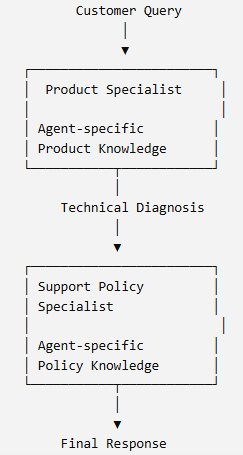

In [44]:
from crewai import Agent, Task, Crew, Process
from crewai.knowledge.source.string_knowledge_source import (
    StringKnowledgeSource
)


# ============================================================
# 1. AGENT-SPECIFIC KNOWLEDGE
# ============================================================

# ------------------------------------------------------------
# Knowledge available ONLY to Product Specialist
# ------------------------------------------------------------

product_knowledge = StringKnowledgeSource(
    content="""
    TechNova AI Enterprise Assistant - Product Information

    Product Name:
    TechNova AI Enterprise Assistant

    Version:
    Enterprise Edition 4.2

    Knowledge Base Connectivity:
    The Enterprise Assistant can connect to:
    - Enterprise document repositories
    - Internal websites
    - CSV and JSON data sources
    - SQL databases
    - Cloud storage

    Supported authentication:
    - OAuth 2.0
    - API keys
    - Service accounts

    Common connection problems:

    1. Authentication Failure
       The system cannot authenticate with the enterprise
       knowledge source.

    2. Permission Error
       The service account does not have permission to access
       the requested documents.

    3. Indexing Failure
       Documents are available but have not been successfully
       indexed.

    4. Embedding Configuration Error
       The configured embedding model is unavailable or
       incompatible.

    5. Network Connectivity Error
       The enterprise firewall may prevent the assistant from
       accessing the knowledge source.

    Diagnostic procedure:

    Step 1:
    Verify that the knowledge source credentials are valid.

    Step 2:
    Verify that the service account has read permission.

    Step 3:
    Check whether documents have been successfully indexed.

    Step 4:
    Verify the embedding model configuration.

    Step 5:
    Check firewall and network connectivity.

    Replacement Eligibility:
    Technical connection problems do not automatically imply
    hardware replacement. A replacement should only be considered
    after the support team determines that the problem is caused
    by defective equipment.
    """
)


# ------------------------------------------------------------
# Knowledge available ONLY to Support Policy Specialist
# ------------------------------------------------------------

policy_knowledge = StringKnowledgeSource(
    content="""
    TechNova AI Enterprise Support Policy

    Warranty:
    All Enterprise Assistant hardware appliances are covered
    by a 24-month warranty beginning from the purchase date.

    Replacement Policy:

    Customers are eligible for hardware replacement when:

    1. The hardware is defective.
    2. The hardware failure has been confirmed by TechNova
       technical support.
    3. The product is still within the warranty period.

    Customers are NOT automatically eligible for replacement
    when the problem is caused by:

    - Incorrect configuration
    - Authentication problems
    - Network problems
    - Missing permissions
    - Software configuration errors
    - Unsupported integrations

    Troubleshooting Requirement:

    Technical support must complete troubleshooting before
    approving a replacement request.

    If the issue is configuration-related, support should first
    provide configuration assistance.

    Escalation:

    If the customer cannot resolve the issue after standard
    troubleshooting, the case should be escalated to Level 2
    Technical Support.

    Level 2 support may approve hardware replacement if a
    hardware defect is subsequently confirmed.

    Customer Communication:

    Support representatives should:

    - Clearly explain the diagnosed problem.
    - Avoid promising replacement before technical verification.
    - Provide the customer with the next recommended action.
    - Explain the escalation process when necessary.
    """
)


# ============================================================
# 2. AGENT 1 - PRODUCT SPECIALIST
# ============================================================

product_specialist = Agent(
    role="Product Technical Specialist",

    goal=(
        "Diagnose customer problems using the technical product "
        "knowledge available to you and provide a clear technical "
        "assessment."
    ),

    backstory=(
        "You are a senior TechNova AI product specialist. "
        "You understand the architecture, configuration and "
        "troubleshooting procedures of the Enterprise Assistant."
    ),

    llm=llm,

    # IMPORTANT:
    # This knowledge belongs ONLY to this agent.
    knowledge_sources=[
        product_knowledge
    ],

    verbose=True
)


# ============================================================
# 3. AGENT 2 - SUPPORT POLICY SPECIALIST
# ============================================================

support_specialist = Agent(
    role="Customer Support Policy Specialist",

    goal=(
        "Determine the appropriate customer response based on "
        "TechNova AI support and warranty policies."
    ),

    backstory=(
        "You are a senior customer support specialist who "
        "understands TechNova AI warranty, replacement and "
        "escalation policies."
    ),

    llm=llm,

    # IMPORTANT:
    # This knowledge belongs ONLY to this agent.
    knowledge_sources=[
        policy_knowledge
    ],

    verbose=True
)


# ============================================================
# 4. TASK 1 - TECHNICAL DIAGNOSIS
# ============================================================

technical_task = Task(
    description="""
    Analyze the following customer problem:

    {customer_query}

    Using your specialized product knowledge:

    1. Identify the most likely technical problem.
    2. Identify possible causes.
    3. Recommend the appropriate troubleshooting steps.
    4. Determine whether the problem appears to be a hardware
       problem or a configuration/software problem.

    Do not make a warranty or replacement decision.
    Your responsibility is only the technical diagnosis.
    """,

    expected_output="""
    A technical diagnosis containing:

    - Problem identification
    - Possible causes
    - Recommended troubleshooting steps
    - Assessment of whether the issue appears to be hardware,
      software, configuration, authentication, permission,
      embedding, or network related.
    """,

    agent=product_specialist
)


# ============================================================
# 5. TASK 2 - POLICY DECISION
# ============================================================

policy_task = Task(
    description="""
    Review the following customer query:

    {customer_query}

    Also review the technical diagnosis produced by the
    Product Technical Specialist.

    Based on your specialized support-policy knowledge:

    1. Determine whether the customer is currently eligible
       for replacement.
    2. Explain the applicable warranty/policy rules.
    3. Determine the next action that support should take.
    4. Determine whether the case should be escalated.

    Do not invent policy rules.

    Produce a customer-facing recommendation.
    """,

    expected_output="""
    A customer support recommendation containing:

    - Replacement eligibility
    - Policy justification
    - Recommended next action
    - Escalation decision
    - Clear customer-facing explanation
    """,

    agent=support_specialist,

    # Agent 2 receives Agent 1's output.
    context=[
        technical_task
    ]
)


# ============================================================
# 6. CREW
# ============================================================

crew = Crew(
    agents=[
        product_specialist,
        support_specialist
    ],

    tasks=[
        technical_task,
        policy_task
    ],

    process=Process.sequential,

    verbose=True
)


# ============================================================
# 7. RUN
# ============================================================

if __name__ == "__main__":

    customer_query = """
    My TechNova AI Enterprise Assistant cannot connect to our
    enterprise knowledge base. We have checked that the system
    is running, but it cannot retrieve any internal documents.

    Can I get a replacement?
    """

    result = await crew.kickoff_async(
        inputs={
            "customer_query": customer_query
        }
    )

    print("\n")
    print("=" * 80)
    print("FINAL CUSTOMER SUPPORT RESPONSE")
    print("=" * 80)
    print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: a3beaebd-1eb7-4960-b806-2416fe1735d2                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔍 Knowledge Retrieval ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Knowledge Retrieval Started                                                                                    │
│  Status: Retrieving...                                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      Analyze the following customer problem:                                                                    │
│                                                                                                                 │
│                                                                                                                 │
│      My TechNova AI Enterprise Assistant cannot connect to our                                                  │
│      enterprise knowledge base. We have checked that the system                                                 │
│      is running, but it cannot retrieve any internal documents.                                                 │
│                                                                                                                 │
│      Can I get a replacement?                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
│      Using your specialized product knowledge:                                                                  │
│                                                                                                                 │
│      1. Identify the most likely technical problem.                                                             │
│      2. Identify possible causes.                                                                               │
│      3. Recommend the appropriate troubleshooting steps.                                                        │
│      4. Determine whether the problem appears to be a hardware                                                  │
│         problem or a configuration/software problem.                                                            │
│                                                                                                                 │
│      Do not make a warranty or replacement decision.                                                            │
│      Your responsibility is only the technical diagnosis.                                                       │
│                                                                                                                 │
│  ID: ab7e74c1-b4ef-4ea4-8279-2df5504801bd                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 📚 Knowledge Retrieved ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Search Query:                                                                                                  │
│  TechNova AI Enterprise Assistant cannot connect to enterprise knowledge base and cannot retrieve internal      │
│  documents; system running. Provide technical diagnosis: identify likely problem, possible causes               │
│  (network/DNS, firewall/proxy, authentication/SSO credentials, OAuth/API keys, permissions/ACL, knowledge base  │
│  indexing/embedding pipeline, document ingestion status, connector configuration, endpoint/URL, SSL/TLS),       │
│  recommended troubleshooting steps (connectivity tests, logs review, retry/backoff, service health checks, KB   │
│  status, embedding/index rebuild, access control verification), and determine whether issue is hardware vs      │
│  software/configuration/authentication/permission/embedding/network related.                                    │
│  Knowledge Retrieved:                                                                                           │
│  Additional Information:                                                                                        │
│      TechNova AI Enterprise Assistant - Product Information                                                     │
│                                                                                                                 │
│      Product Name:                                                                                              │
│      TechNova AI Enterprise Assistant                                                                           │
│                                                                                                                 │
│      Version:                                                                                                   │
│      Enterprise Edition 4.2                                                                                     │
│                                                                                                                 │
│      Knowledge Base Connectivity:                                                                               │
│      The Enterprise Assistant can connect to:                                                                   │
│      - Enterprise document repositories                                                                         │
│      - Internal websites                                                                                        │
│      - CSV and JSON data sources                                                                                │
│      - SQL databases                                                                                            │
│      - Cloud storage                                                                                            │
│                                                                                                                 │
│      Supported authentication:                                                                                  │
│      - OAuth 2.0                                                                                                │
│      - API keys                                                                                                 │
│      - Service accounts                                                                                         │
│                                                                                                                 │
│      Common conne...                                                                                            │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Product Technical Specialist                                                                            │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Analyze the following customer problem:                                                                    │
│                                                                                                                 │
│                                                                                                                 │
│      My TechNova AI Enterprise Assistant cannot connect to our                                                  │
│      enterprise knowledge base. We have checked that the system                                                 │
│      is running, but it cannot retrieve any internal documents.                                                 │
│                                                                                                                 │
│      Can I get a replacement?                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
│      Using your specialized product knowledge:                                                                  │
│                                                                                                                 │
│      1. Identify the most likely technical problem.                                                             │
│      2. Identify possible causes.                                                                               │
│      3. Recommend the appropriate troubleshooting steps.                                                        │
│      4. Determine whether the problem appears to be a hardware                                                  │
│         problem or a configuration/software problem.                                                            │
│                                                                                                                 │
│      Do not make a warranty or replacement decision.                                                            │
│      Your responsibility is only the technical diagnosis.                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Customer Support Policy Specialist                                                                      │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Review the following customer query:                                                                       │
│                                                                                                                 │
│                                                                                                                 │
│      My TechNova AI Enterprise Assistant cannot connect to our                                                  │
│      enterprise knowledge base. We have checked that the system                                                 │
│      is running, but it cannot retrieve any internal documents.                                                 │
│                                                                                                                 │
│      Can I get a replacement?                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
│      Also review the technical diagnosis produced by the                                                        │
│      Product Technical Specialist.                                                                              │
│                                                                                                                 │
│      Based on your specialized support-policy knowledge:                                                        │
│                                                                                                                 │
│      1. Determine whether the customer is currently eligible                                                    │
│         for replacement.                                                                                        │
│      2. Explain the applicable warranty/policy rules.                                                           │
│      3. Determine the next action that support should take.                                                     │
│      4. Determine whether the case should be escalated.                                                         │
│                                                                                                                 │
│      Do not invent policy rules.                                                                                │
│                                                                                                                 │
│      Produce a customer-facing recommendation.                                                                  │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Customer Support Policy Specialist                                                                      │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ## Replacement eligibility (is a replacement allowed right now?)                                               │
│  **Not yet.** Based on the reported symptom (“system is running” but it **cannot retrieve any internal          │
│  documents**) and the technical diagnosis, this is most consistent with **authentication/authorization**,       │
│  **network/firewall**, **indexing/embedding configuration**, or **permissions**—which are **explicitly          │
│  excluded from automatic replacement eligibility** under TechNova AI’s Enterprise Support Policy.               │
│                                                                                                                 │
│  A customer is eligible for **hardware replacement** only when:                                                 │
│  1) the hardware is **defective**,                                                                              │
│  2) the defect is **confirmed by TechNova technical support**, and                                              │
│  3) the unit is **within the 24-month warranty period**.                                                        │
│                                                                                                                 │
│  At this stage, the evidence points to a **configuration/connectivity/pipeline** issue rather than a hardware   │
│  defect.                                                                                                        │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  ## Policy justification (why replacement is not automatic)                                                     │
│  TechNova’s Replacement Policy states customers are **NOT automatically eligible for replacement** when the     │
│  problem is caused by:                                                                                          │
│  - **Incorrect configuration**                                                                                  │
│  - **Authentication problems**                                                                                  │
│  - **Network problems**                                                                                         │
│  - **Missing permissions**                                                                                      │
│  - **Software configuration errors**                                                                            │
│  - **Unsupported integrations**                                                                                 │
│                                                                                                                 │
│  Your case matches those categories: the assistant is running, but retrieval fails for internal                 │
│  documents—typically indicating the knowledge-base connectivity pipeline (auth/permissions/network) and/or      │
│  indexing/embedding is not functioning, not that the appliance hardware is defective.                           │
│                                                        

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      Review the following customer query:                                                                       │
│                                                                                                                 │
│                                                                                                                 │
│      My TechNova AI Enterprise Assistant cannot connect to our                                                  │
│      enterprise knowledge base. We have checked that the system                                                 │
│      is running, but it cannot retrieve any internal documents.                                                 │
│                                                                                                                 │
│      Can I get a replacement?                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
│      Also review the technical diagnosis produced by the                                                        │
│      Product Technical Specialist.                                                                              │
│                                                                                                                 │
│      Based on your specialized support-policy knowledge:                                                        │
│                                                                                                                 │
│      1. Determine whether the customer is currently eligible                                                    │
│         for replacement.                                                                                        │
│      2. Explain the applicable warranty/policy rules.                                                           │
│      3. Determine the next action that support should take.                                                     │
│      4. Determine whether the case should be escalated.                                                         │
│                                                                                                                 │
│      Do not invent policy rules.                                                                                │
│                                                                                                                 │
│      Produce a customer-facing recommendation.                                                                  │
│                                                                                                                 │
│  Agent: Customer Support Policy Specialist                                                                      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



FINAL CUSTOMER SUPPORT RESPONSE
## Replacement eligibility (is a replacement allowed right now?)
**Not yet.** Based on the reported symptom (“system is running” but it **cannot retrieve any internal documents**) and the technical diagnosis, this is most consistent with **authentication/authorization**, **network/firewall**, **indexing/embedding configuration**, or **permissions**—which are **explicitly excluded from automatic replacement eligibility** under TechNova AI’s Enterprise Support Policy.

A customer is eligible for **hardware replacement** only when:
1) the hardware is **defective**,  
2) the defect is **confirmed by TechNova technical support**, and  
3) the unit is **within the 24-month warranty period**.

At this stage, the evidence points to a **configuration/connectivity/pipeline** issue rather than a hardware defect.

---

## Policy justification (why replacement is not automatic)
TechNova’s Replacement Policy states customers are **NOT automatically eligible for repl

# **Agent and Crew Knowledge**

IT Incident Resolution Crew, because it naturally separates company-wide policies from specialist technical knowledge.

Scenario: A company has an internal AI support crew:

**Technical Specialist** — diagnoses infrastructure problems. It needs specialized knowledge about the company's systems.

**Support Coordinator** — communicates the resolution to employees. It only needs the common company IT policies.

**Crew-wide knowledge** — IT support policies that both agents need.

**Agent-specific knowledge** — infrastructure specifications that only the Technical Specialist needs.

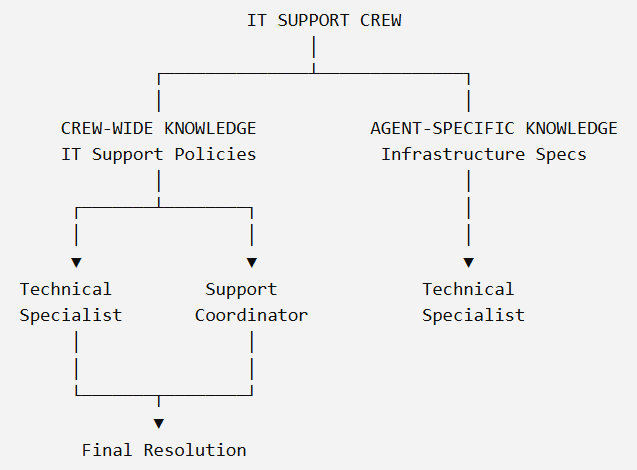

In [45]:
from crewai import Agent, Task, Crew, Process
from crewai.knowledge.source.string_knowledge_source import (
    StringKnowledgeSource
)


# ============================================================
# 1. CREW-WIDE KNOWLEDGE
# ============================================================
# This knowledge is available to BOTH agents.

crew_knowledge = StringKnowledgeSource(
    content="""
    ACME Corporation - IT Support Policy

    1. Incident Priority

    P1 - Critical:
    A complete production outage or security incident affecting
    multiple departments.

    P2 - High:
    A major business application is unavailable to a department
    or a critical business process is affected.

    P3 - Medium:
    An individual employee or small group is experiencing a
    problem that has a workaround.

    P4 - Low:
    General questions, minor issues, or requests for information.

    2. Escalation Policy

    P1 incidents must immediately be escalated to the
    Infrastructure Team.

    P2 incidents should be escalated if they cannot be resolved
    within 30 minutes.

    P3 incidents should first go through standard troubleshooting.

    3. Communication Policy

    Support staff must:

    - Clearly explain the problem.
    - Avoid making unsupported technical claims.
    - Tell the employee what action will be taken.
    - Provide an escalation path when necessary.

    4. Incident Closure

    An incident may be closed only when:

    - The problem has been resolved, or
    - The employee confirms that the workaround is acceptable.

    5. Security

    Support staff must never request or disclose employee
    passwords, authentication tokens, or private credentials.
    """
)


# ============================================================
# 2. AGENT-SPECIFIC KNOWLEDGE
# ============================================================
# This knowledge is available ONLY to the Technical Specialist.

specialist_knowledge = StringKnowledgeSource(
    content="""
    ACME Corporation - Production Infrastructure Specifications

    Application:
    ACME Order Management System (OMS)

    Production Architecture:

    - Application servers: 4
    - Database: PostgreSQL primary + read replica
    - Cache: Redis
    - Load balancer: HAProxy
    - Monitoring: Prometheus and Grafana

    Normal Operating Characteristics:

    Application server CPU:
    20-60%

    Application server memory:
    40-70%

    PostgreSQL connection pool:
    20-80 active connections

    Redis memory utilization:
    Normally below 70%

    Common Failure Conditions:

    1. Database Connection Exhaustion

    If PostgreSQL active connections exceed 95% of the configured
    connection pool, new application requests may fail.

    2. Redis Failure

    If Redis becomes unavailable, order processing may become
    significantly slower.

    3. Application Server Failure

    If more than two application servers become unavailable,
    the load balancer may not be able to handle normal traffic.

    4. Database Replication Lag

    Replication lag above 60 seconds may cause stale information
    to appear in read operations.

    Diagnostic Procedure:

    Step 1:
    Check application server health.

    Step 2:
    Check PostgreSQL connection utilization.

    Step 3:
    Check Redis availability.

    Step 4:
    Check database replication lag.

    Step 5:
    Check HAProxy backend health.

    Important:

    Do not restart production database services without
    Infrastructure Team approval.
    """
)


# ============================================================
# 3. TECHNICAL SPECIALIST
# ============================================================

technical_specialist = Agent(
    role="Production Infrastructure Specialist",

    goal=(
        "Diagnose production infrastructure incidents using "
        "the available technical knowledge and recommend "
        "appropriate technical actions."
    ),

    backstory=(
        "You are a senior infrastructure engineer responsible "
        "for diagnosing problems in ACME's production systems."
    ),

    llm=llm,

    # Agent-specific knowledge
    knowledge_sources=[
        specialist_knowledge
    ],

    verbose=True
)


# ============================================================
# 4. GENERAL SUPPORT COORDINATOR
# ============================================================

support_coordinator = Agent(
    role="IT Support Coordinator",

    goal=(
        "Classify incidents according to company policy and "
        "communicate appropriate actions to employees."
    ),

    backstory=(
        "You are an experienced IT support coordinator who "
        "handles employee incidents and coordinates escalation."
    ),

    llm=llm,

    # NO agent-specific knowledge
    #
    # Therefore this agent receives ONLY the crew-wide knowledge.

    verbose=True
)


# ============================================================
# 5. TECHNICAL DIAGNOSIS TASK
# ============================================================

diagnosis_task = Task(
    description="""
    Diagnose the following production incident:

    {incident}

    Determine:

    1. The most likely technical cause.
    2. The relevant infrastructure component.
    3. The diagnostic evidence that should be checked.
    4. The recommended technical action.
    5. Whether Infrastructure Team approval is required.

    Use your specialized infrastructure knowledge.
    Do not make assumptions that are unsupported by the
    available technical information.
    """,

    expected_output="""
    A technical incident diagnosis containing:

    - Probable cause
    - Affected component
    - Diagnostic checks
    - Recommended technical action
    - Approval/escalation requirement
    """,

    agent=technical_specialist
)


# ============================================================
# 6. SUPPORT COORDINATION TASK
# ============================================================

support_task = Task(
    description="""
    Handle the following incident:

    {incident}

    Review the technical diagnosis from the Infrastructure
    Specialist.

    Using the company-wide IT support policies:

    1. Determine the incident priority.
    2. Determine whether escalation is required.
    3. Determine what should be communicated to the employee.
    4. Identify the appropriate next action.

    Do not invent technical details that are not present in
    the diagnosis.
    """,

    expected_output="""
    A support response containing:

    - Incident priority
    - Escalation decision
    - Recommended action
    - Employee-facing explanation
    """,

    agent=support_coordinator,

    # Pass the Technical Specialist's output to the coordinator.
    context=[
        diagnosis_task
    ]
)


# ============================================================
# 7. CREW
# ============================================================

crew = Crew(
    agents=[
        technical_specialist,
        support_coordinator
    ],

    tasks=[
        diagnosis_task,
        support_task
    ],

    process=Process.sequential,

    # CREW-WIDE KNOWLEDGE
    # Both agents receive this knowledge.
    knowledge_sources=[
        crew_knowledge
    ],

    verbose=True
)


# ============================================================
# 8. RUN
# ============================================================

if __name__ == "__main__":

    incident = """
    Employees in the Finance department report that the ACME
    Order Management System is extremely slow.

    Some employees receive timeout errors when submitting orders.
    The problem started approximately 15 minutes ago.

    Other departments are also beginning to report slow response
    times.
    """

    result = await crew.kickoff_async(
        inputs={
            "incident": incident
        }
    )

    print("\n")
    print("=" * 80)
    print("FINAL IT SUPPORT RESPONSE")
    print("=" * 80)
    print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 585f7eee-9bcf-4714-8b83-9d27d21dda1a                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔍 Knowledge Retrieval ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Knowledge Retrieval Started                                                                                    │
│  Status: Retrieving...                                                                                          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      Diagnose the following production incident:                                                                │
│                                                                                                                 │
│                                                                                                                 │
│      Employees in the Finance department report that the ACME                                                   │
│      Order Management System is extremely slow.                                                                 │
│                                                                                                                 │
│      Some employees receive timeout errors when submitting orders.                                              │
│      The problem started approximately 15 minutes ago.                                                          │
│                                                                                                                 │
│      Other departments are also beginning to report slow response                                               │
│      times.                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
│      Determine:                                                                                                 │
│                                                                                                                 │
│      1. The most likely technical cause.                                                                        │
│      2. The relevant infrastructure component.                                                                  │
│      3. The diagnostic evidence that should be checked.                                                         │
│      4. The recommended technical action.                                                                       │
│      5. Whether Infrastructure Team approval is required.                                                       │
│                                                                                                                 │
│      Use your specialized infrastructure knowledge.                                                             │
│      Do not make assumptions that are unsupported by the                                                        │
│      available technical information.                                                                           │
│                                                                                                                 │
│  ID: 965e37a5-70c2-475b-84ed-586de9973174                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 📚 Knowledge Retrieved ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Search Query:                                                                                                  │
│  ACME Order Management System production incident diagnosis: sudden onset ~15 minutes ago, widespread slowness  │
│  across multiple departments, Finance users report extremely slow system and order submission timeouts.         │
│  Identify (1) most likely technical cause, (2) affected infrastructure component, (3) specific diagnostic       │
│  evidence to check (e.g., service health, latency, timeouts, logs, metrics, dependencies,                       │
│  DB/cache/network/load balancer), (4) recommended technical remediation steps, (5) whether Infrastructure Team  │
│  approval/escalation is required.                                                                               │
│  Knowledge Retrieved:                                                                                           │
│  Additional Information:                                                                                        │
│      ACME Corporation - Production Infrastructure Specifications                                                │
│                                                                                                                 │
│      Application:                                                                                               │
│      ACME Order Management System (OMS)                                                                         │
│                                                                                                                 │
│      Production Architecture:                                                                                   │
│                                                                                                                 │
│      - Application servers: 4                                                                                   │
│      - Database: PostgreSQL primary + read replica                                                              │
│      - Cache: Redis                                                                                             │
│      - Load balancer: HAProxy                                                                                   │
│      - Monitoring: Prometheus and Grafana                                                                       │
│                                                                                                                 │
│      Normal Operating Characteristics:                                                                          │
│                                                                                                                 │
│      Application server CPU:                                                                                    │
│      20-60%                                                                                                     │
│                                                                                                                 │
│      Application server memory:                                                                                 │
│      40-70%                                                                                                     │
│                                                                                                                 │
│      PostgreSQL connection poo...                                                                               │
│                                                                                                                 │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Production Infrastructure Specialist                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Diagnose the following production incident:                                                                │
│                                                                                                                 │
│                                                                                                                 │
│      Employees in the Finance department report that the ACME                                                   │
│      Order Management System is extremely slow.                                                                 │
│                                                                                                                 │
│      Some employees receive timeout errors when submitting orders.                                              │
│      The problem started approximately 15 minutes ago.                                                          │
│                                                                                                                 │
│      Other departments are also beginning to report slow response                                               │
│      times.                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
│      Determine:                                                                                                 │
│                                                                                                                 │
│      1. The most likely technical cause.                                                                        │
│      2. The relevant infrastructure component.                                                                  │
│      3. The diagnostic evidence that should be checked.                                                         │
│      4. The recommended technical action.                                                                       │
│      5. Whether Infrastructure Team approval is required.                                                       │
│                                                                                                                 │
│      Use your specialized infrastructure knowledge.                                                             │
│      Do not make assumptions that are unsupported by the                                                        │
│      available technical information.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: IT Support Coordinator                                                                                  │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  - **Incident priority:** **P2 - High** (major business application is experiencing extreme slowness/timeouts   │
│  across multiple departments; order submission is impacted)                                                     │
│                                                                                                                 │
│  - **Escalation decision:** **Escalate to Infrastructure Team** (and do so immediately).                        │
│    - Rationale: Symptoms indicate a shared infrastructure bottleneck affecting multiple departments; this is    │
│  time-sensitive and may require infrastructure-level mitigation/validation.                                     │
│                                                                                                                 │
│  - **Recommended action (next action):**                                                                        │
│    1. **Start/continue live verification of dependency saturation** using existing monitoring:                  │
│       - Check **PostgreSQL active connections / connection pool utilization** and whether it is near/exceeding  │
│  the threshold (e.g., **>95%** of configured pool) and whether connection acquisition waits are elevated.       │
│       - In parallel, check **Redis availability/latency** and **HAProxy backend health/queue/response times**.  │
│    2. **If PostgreSQL connection exhaustion is confirmed:**                                                     │
│       - Identify the specific endpoints/queries driving the connection usage (from available slow query/app     │
│  metrics/traces).                                                                                               │
│       - Apply **safe mitigation at the application/traffic level** (e.g., reduce concurrency / rate-limit the   │
│  order submission workflow if an approved control exists; validate retry/backoff behavior to avoid a retry      │
│  storm).                                                                                                        │
│       - **Do not restart PostgreSQL** (or perform failover/major DB configuration changes) unless               │
│  Infrastructure Team approves explicitly.                                                                       │
│    3. **If Redis is confirmed degraded/unavailable:** restore Redis service/latency using standard operational  │
│  remediation, and verify OMS timeouts reduce.                                                                   │
│    4. **If HAProxy backend health is degraded:** investigate and remediate unhealthy backends/traffic routing.  │
│                                                                                                                 │
│  - **Employee-facing explanation (what we communicate):**                                                       │
│    > We’re seeing **widespread slowness and timeouts** in the ACME Order Management System that started about   │
│  **15 minutes ago**. This appears to be caused by a **shared backend dependency becoming overloaded**, which    │
│  can make requests queue up and exceed timeout limits.                                                          │
│    >                                                                                                            │
│    > **What we’re doing now:** Our Infrastructure Team 

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      Handle the following incident:                                                                             │
│                                                                                                                 │
│                                                                                                                 │
│      Employees in the Finance department report that the ACME                                                   │
│      Order Management System is extremely slow.                                                                 │
│                                                                                                                 │
│      Some employees receive timeout errors when submitting orders.                                              │
│      The problem started approximately 15 minutes ago.                                                          │
│                                                                                                                 │
│      Other departments are also beginning to report slow response                                               │
│      times.                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
│      Review the technical diagnosis from the Infrastructure                                                     │
│      Specialist.                                                                                                │
│                                                                                                                 │
│      Using the company-wide IT support policies:                                                                │
│                                                                                                                 │
│      1. Determine the incident priority.                                                                        │
│      2. Determine whether escalation is required.                                                               │
│      3. Determine what should be communicated to the employee.                                                  │
│      4. Identify the appropriate next action.                                                                   │
│                                                                                                                 │
│      Do not invent technical details that are not present in                                                    │
│      the diagnosis.                                                                                             │
│                                                                                                                 │
│  Agent: IT Support Coordinator                                                                                  │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯



FINAL IT SUPPORT RESPONSE
- **Incident priority:** **P2 - High** (major business application is experiencing extreme slowness/timeouts across multiple departments; order submission is impacted)

- **Escalation decision:** **Escalate to Infrastructure Team** (and do so immediately).  
  - Rationale: Symptoms indicate a shared infrastructure bottleneck affecting multiple departments; this is time-sensitive and may require infrastructure-level mitigation/validation.  

- **Recommended action (next action):**
  1. **Start/continue live verification of dependency saturation** using existing monitoring:
     - Check **PostgreSQL active connections / connection pool utilization** and whether it is near/exceeding the threshold (e.g., **>95%** of configured pool) and whether connection acquisition waits are elevated.
     - In parallel, check **Redis availability/latency** and **HAProxy backend health/queue/response times**.
  2. **If PostgreSQL connection exhaustion is confirmed:**  
     - 

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 585f7eee-9bcf-4714-8b83-9d27d21dda1a                                                                       │
│  Final Output: - **Incident priority:** **P2 - High** (major business application is experiencing extreme       │
│  slowness/timeouts across multiple departments; order submission is impacted)                                   │
│                                                                                                                 │
│  - **Escalation decision:** **Escalate to Infrastructure Team** (and do so immediately).                        │
│    - Rationale: Symptoms indicate a shared infrastructure bottleneck affecting multiple departments; this is    │
│  time-sensitive and may require infrastructure-level mitigation/validation.                                     │
│                                                                                                                 │
│  - **Recommended action (next action):**                                                                        │
│    1. **Start/continue live verification of dependency saturation** using existing monitoring:                  │
│       - Check **PostgreSQL active connections / connection pool utilization** and whether it is near/exceeding  │
│  the threshold (e.g., **>95%** of configured pool) and whether connection acquisition waits are elevated.       │
│       - In parallel, check **Redis availability/latency** and **HAProxy backend health/queue/response times**.  │
│    2. **If PostgreSQL connection exhaustion is confirmed:**                                                     │
│       - Identify the specific endpoints/queries driving the connection usage (from available slow query/app     │
│  metrics/traces).                                                                                               │
│       - Apply **safe mitigation at the application/traffic level** (e.g., reduce concurrency / rate-limit the   │
│  order submission workflow if an approved control exists; validate retry/backoff behavior to avoid a retry      │
│  storm).                                                                                                        │
│       - **Do not restart PostgreSQL** (or perform failover/major DB configuration changes) unless               │
│  Infrastructure Team approves explicitly.                                                                       │
│    3. **If Redis is confirmed degraded/unavailable:** restore Redis service/latency using standard operational  │
│  remediation, and verify OMS timeouts reduce.                                                                   │
│    4. **If HAProxy backend health is degraded:** investigate and remediate unhealthy backends/traffic routing.  │
│                                                                                                                 │
│  - **Employee-facing explanation (what we communicate):**                                                       │
│    > We’re seeing **widespread slowness and timeouts** in the ACME Order Management System that started about   │
│  **15 minutes ago**. This appears to be caused by a **shared backend dependency becoming overloaded**, which    │
│  can make requests queue up and exceed timeout limits.                                                          │
│    >                                                                                                            │
│    > **What we’re doing now:** Our Infrastructure Team